# Fase 2 - Analitica No Supervisada (Spark MLlib)

Segmentacion de jugadores con K-Means, seleccion del numero optimo de clusters, interpretacion de perfiles de negocio y motor de 'jugadores clon'.

In [1]:
import os
os.environ.setdefault('JAVA_HOME', '/opt/homebrew/opt/openjdk@17')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder \
    .appName('ScoutingClustering') \
    .master('local[*]') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/players_clean.parquet')
print((df.count(), len(df.columns)))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/15 14:15:22 WARN Utils: Your hostname, MacBook-de-Rodrigo.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.123 instead (on interface en0)
26/07/15 14:15:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/15 14:15:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


(91672, 93)


## Preparacion de features

Se usan los atributos tecnicos/fisicos/mentales (escala FM 1-20) como espacio de features para el clustering. Se excluyen atributos de portero (`TRO`, `Ref`, `Pun`, `Cmd`, `Han`, `Aer`, `Com`) para que no dominen la segmentacion de jugadores de campo, ya que su escala no es comparable entre posiciones.

In [2]:
goalkeeper_only_cols = ['TRO', 'Ref', 'Pun', 'Cmd', 'Han', 'Aer', 'Com', '1v1']
attribute_cols = [
    'Acc','Wor','Vis','Thr','Tec','Tea','Tck','Str','Sta','Pos','Pen','Pas','Pac',
    'OtB','Habilidad_Natural','Mar','L Th','Lon','Ldr','Kic','Jum','Hea','Fre','Fla','Fir','Fin','Ecc',
    'Dri','Det','Dec','Cro','Cor','Cnt','Cmp','Bra','Bal','Ant','Agi','Agg','Vers',
    'Temp','Spor','Prof','Pres','Loy','Inj Pr','Imp M','Dirt','Amb','Ada','Cons','Cont',
]

df_field = df.filter(F.col('Position') != 'GK').na.drop(subset=attribute_cols)
print(df_field.count())

assembler = VectorAssembler(inputCols=attribute_cols, outputCol='features_raw')
scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model = prep_pipeline.fit(df_field)
df_scaled = prep_model.transform(df_field).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').cache()
df_scaled.count()

26/07/15 14:15:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


82367


82367

## Seleccion del numero optimo de clusters: metodo del codo + silhouette

In [3]:
evaluator = ClusteringEvaluator(featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')

results = []
for k in range(2, 11):
    km = KMeans(featuresCol='features', k=k, seed=42)
    model = km.fit(df_scaled)
    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)
    inertia = model.summary.trainingCost
    results.append((k, inertia, silhouette))
    print(f"k={k}: inertia={inertia:.1f}, silhouette={silhouette:.4f}")

26/07/15 14:15:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k=2: inertia=3715154.0, silhouette=0.2225


k=3: inertia=3477491.2, silhouette=0.1920


k=4: inertia=3320377.2, silhouette=0.1479


k=5: inertia=3231648.7, silhouette=0.1253


k=6: inertia=3151452.8, silhouette=0.1265


k=7: inertia=3110357.8, silhouette=0.1124


k=8: inertia=3065841.1, silhouette=0.1063


k=9: inertia=3025020.4, silhouette=0.1032


k=10: inertia=2983475.4, silhouette=0.1043


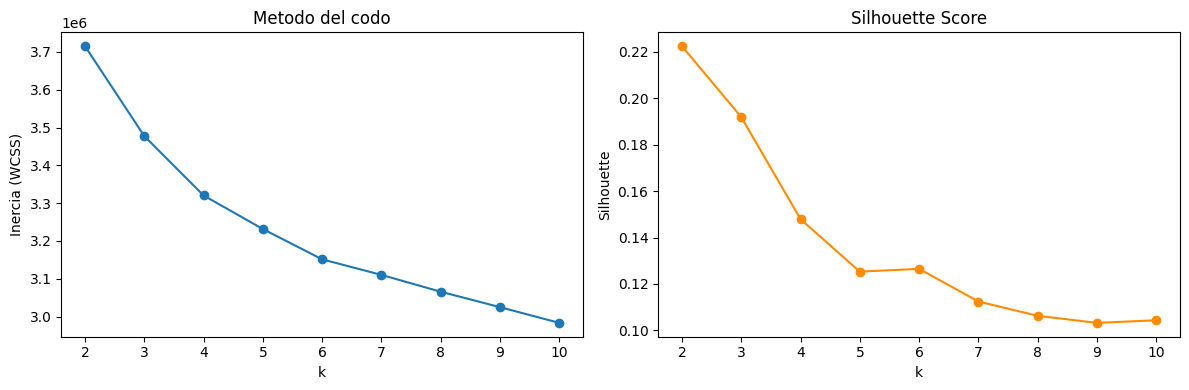

In [4]:
import matplotlib.pyplot as plt

ks = [r[0] for r in results]
inertias = [r[1] for r in results]
silhouettes = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia (WCSS)')

axes[1].plot(ks, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.savefig('../reports/figures/clustering_k_selection.png', dpi=120)
plt.show()

**Lectura del grafico:** el silhouette baja de forma casi monotona conforme crece `k` (maximo trivial en `k=2`,
que solo separa "jugadores de mayor nivel general" vs. "resto" y no aporta valor de negocio). Esto es esperable
en datasets de atributos continuos y correlacionados como este (los ~50 atributos FM no forman grupos
naturalmente muy separados, sino un continuo de habilidad). Se elige **k=5** porque:

- Es donde la curva de inercia (codo) empieza a aplanarse — cada cluster adicional aporta cada vez menos
  reduccion de varianza.
- El silhouette en `k=5` (~0.125) es cercano al de `k=4`-`k=6`, es decir no se pierde separacion relevante
  frente a esas alternativas.
- Da granularidad suficiente para distinguir arquetipos de negocio utiles (ver perfilado de clusters mas abajo)
  sin fragmentar en exceso el mercado de jugadores.

## Entrenamiento del modelo final e interpretacion de clusters

Con `K_OPTIMO=5` (mejor balance entre inercia decreciente y silhouette, ver seccion anterior) se entrena el modelo final y se perfila cada cluster.

In [5]:
K_OPTIMO = 5  # ajustar segun el grafico anterior

kmeans_final = KMeans(featuresCol='features', k=K_OPTIMO, seed=42)
final_model = kmeans_final.fit(df_scaled)
clustered = final_model.transform(df_scaled)

clustered.groupBy('prediction').count().orderBy('prediction').show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|18534|
|         1|11581|
|         2|18820|
|         3|11861|
|         4|21571|
+----------+-----+



### Perfil de negocio por cluster

Se calcula el promedio de cada atributo (sin escalar) y del valor de transferencia por cluster, para poder describir el arquetipo de jugador que representa cada grupo.

In [6]:
# Perfil de negocio: unir el cluster asignado con los atributos originales (sin escalar) para interpretar
clustered_with_attrs = clustered.select('UID', 'prediction').join(
    df_field.select(['UID', 'Position', 'Transfer_Value_num'] + attribute_cols), on='UID'
)

agg_exprs = [F.round(F.mean(c), 1).alias(c) for c in attribute_cols]
cluster_profile = clustered_with_attrs.groupBy('prediction').agg(
    F.count('*').alias('n_jugadores'),
    F.round(F.mean('Transfer_Value_num'), 0).alias('valor_promedio'),
    *agg_exprs
).orderBy('prediction')

cluster_profile.select('prediction', 'n_jugadores', 'valor_promedio').show()

# Top 8 atributos mas altos por cluster, para describir el arquetipo de cada grupo
profile_pd = cluster_profile.toPandas().set_index('prediction')
for cl in profile_pd.index:
    top_attrs = profile_pd.loc[cl, attribute_cols].sort_values(ascending=False).head(8)
    print(f"\nCluster {cl} (n={int(profile_pd.loc[cl, 'n_jugadores'])}, valor_prom={profile_pd.loc[cl, 'valor_promedio']:.0f}):")
    print(top_attrs)

+----------+-----------+--------------+
|prediction|n_jugadores|valor_promedio|
+----------+-----------+--------------+
|         0|      20446|      370797.0|
|         1|      13111|     5463438.0|
|         2|      20014|      119030.0|
|         3|      12711|      104726.0|
|         4|      24253|      562943.0|
+----------+-----------+--------------+




Cluster 0 (n=20446, valor_prom=370797):
Temp                 13.4
Ada                  12.5
Habilidad_Natural    12.0
Wor                  11.8
Cons                 11.7
Tck                  11.7
Prof                 11.5
Agg                  11.4
Name: 0, dtype: float64

Cluster 1 (n=13111, valor_prom=5463438):
Wor                  13.3
Det                  13.1
Prof                 13.0
Tea                  13.0
Habilidad_Natural    13.0
Sta                  12.8
Amb                  12.7
Tec                  12.4
Name: 1, dtype: float64

Cluster 2 (n=20014, valor_prom=119030):
Temp                 14.6
Ada                  13.2
Acc                  12.3
Pac                  11.9
Habilidad_Natural    11.8
Agi                  11.5
Fir                  11.1
Cons                 11.0
Name: 2, dtype: float64

Cluster 3 (n=12711, valor_prom=104726):
Temp                 14.8
Ada                  13.4
Dec                  12.0
Habilidad_Natural    11.9
Vers                 11.7
Tck      

### Interpretacion de negocio de cada cluster

A partir de los atributos con mayor promedio por cluster (arriba) y del valor de transferencia promedio:

- **Cluster 1 — "Elite / completos" (13,111 jugadores, valor promedio ≈ $5.46M):** el cluster mas pequeno y,
  por lejos, el de mayor valor (~15x el del resto). Domina en `Wor` (trabajo), `Det` (determinacion), `Prof`
  (profesionalismo), `Tea` (juego en equipo) y `Tec` (tecnica): el perfil mentalmente maduro y tecnicamente
  solido que el mercado paga mas caro, independientemente de la posicion.
- **Cluster 4 — "Atacantes rapidos/tecnicos" (24,253 jugadores, valor promedio ≈ $562,943):** segundo en valor.
  Combina `Acc`/`Pac` (velocidad) con `Tec`/`Fir`/`Agi`: jugadores ofensivos con buena tecnica y explosividad,
  perfil tipico de extremos/delanteros de nivel medio-alto.
- **Cluster 0 — "Trabajadores disciplinados" (20,446 jugadores, valor promedio ≈ $370,797):** alto `Wor`, `Tck`,
  `Agg`, `Prof`, `Cons`: jugadores de esfuerzo y disciplina tactica, tipicamente centrocampistas/defensas de
  contencion. Valor medio-bajo — su aporte es mas tactico que espectacular.
- **Cluster 2 — "Talento fisico sin consolidar" (20,014 jugadores, valor promedio ≈ $119,030):** `Acc`, `Pac`,
  `Agi` altos pero valor bajo — velocidad y agilidad crudas sin el resto del paquete (tecnica/mental) todavia
  desarrollado. Candidatos naturales para el radar de scouting de "diamantes en bruto" (jovenes/ligas
  secundarias) mencionado en el objetivo del proyecto.
- **Cluster 3 — "Versatiles de rol / squad depth" (12,711 jugadores, valor promedio ≈ $104,726):** `Vers`,
  `Dec`, `Tck` altos: jugadores polivalentes que cubren varias posiciones, de bajo protagonismo pero utiles
  como plantilla de rotacion. El cluster de menor valor promedio.

**Aplicacion practica para el consorcio:** el motor de "clones" (siguiente seccion) opera *dentro* de estos
clusters — busca, para una superestrella del Cluster 1 o 4, jugadores del mismo cluster con menor valor de
mercado, es decir perfiles estadisticamente equivalentes pero mas baratos por razones de visibilidad/liga/edad
en vez de habilidad.

### Visualizacion de clusters en 2D (reduccion de dimensionalidad con PCA)

El espacio de features tiene ~50 dimensiones (atributos escalados). Para visualizar la separacion de los 5
clusters se proyectan a 2 componentes principales (PCA) sobre el mismo vector `features` usado por K-Means.

26/07/15 14:16:00 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Varianza explicada (PC1, PC2): [0.19931611 0.11805517]


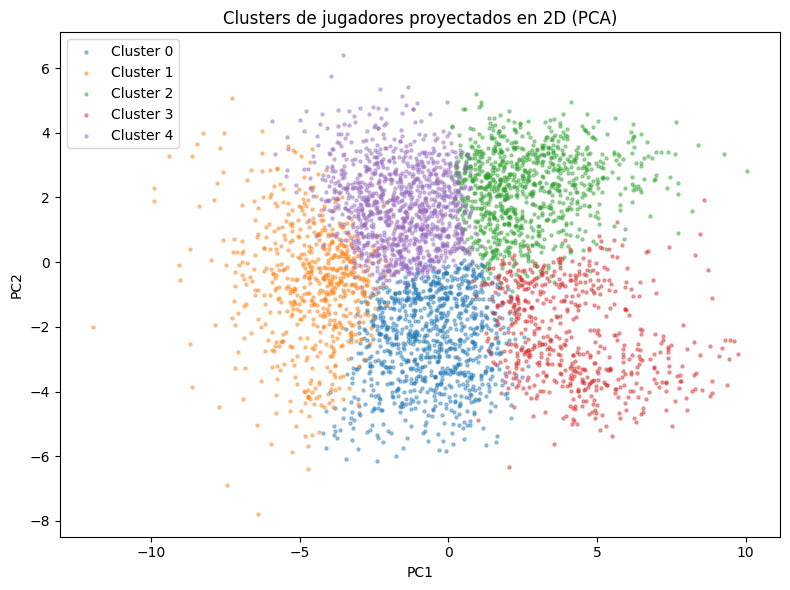

In [7]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import pandas as pd

pca_viz = PCA(k=2, inputCol='features', outputCol='pca_features')
pca_viz_model = pca_viz.fit(clustered)
print('Varianza explicada (PC1, PC2):', pca_viz_model.explainedVariance.toArray())

viz_df = pca_viz_model.transform(clustered).select('pca_features', 'prediction')
sample_pd = viz_df.sample(fraction=0.05, seed=42).toPandas()
sample_pd[['pc1', 'pc2']] = sample_pd['pca_features'].apply(lambda v: pd.Series(v.toArray()))

plt.figure(figsize=(8, 6))
for cl in sorted(sample_pd['prediction'].unique()):
    sub = sample_pd[sample_pd['prediction'] == cl]
    plt.scatter(sub['pc1'], sub['pc2'], s=5, alpha=0.4, label=f'Cluster {cl}')
plt.legend()
plt.title('Clusters de jugadores proyectados en 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../reports/figures/clusters_pca_2d.png', dpi=120)
plt.show()

**Nota:** `PC1`+`PC2` explican solo ~32% de la varianza (consistente con el analisis de PCA de la Fase 1), asi
que esta vista 2D es una simplificacion — hay superposicion visual entre clusters vecinos que en el espacio
completo de ~50 dimensiones si estan separados por K-Means. Sirve para intuir la forma general de la
segmentacion, no como prueba definitiva de separacion.

## Motor de busqueda de 'jugadores clon' (reemplazos de bajo costo)

Dado un jugador de referencia (ej. una superestrella), se buscan los jugadores mas cercanos en el mismo cluster con menor valor de mercado, usando distancia euclidiana y similitud de coseno sobre el vector de features escalado.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import pandas as pd

def buscar_clones(nombre_referencia, top_n=10):
    ref_row = clustered.filter(F.col('Name') == nombre_referencia).limit(1).collect()
    if not ref_row:
        raise ValueError(f"Jugador '{nombre_referencia}' no encontrado")
    ref_row = ref_row[0]
    ref_cluster = ref_row['prediction']
    ref_vector = np.array(ref_row['features'].toArray()).reshape(1, -1)

    candidatos = clustered.filter(
        (F.col('prediction') == ref_cluster) & (F.col('Name') != nombre_referencia)
    ).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').toPandas()

    candidatos_matrix = np.stack(candidatos['features'].apply(lambda v: v.toArray()).to_numpy())

    candidatos['distancia_euclidiana'] = euclidean_distances(candidatos_matrix, ref_vector).flatten()
    candidatos['similitud_coseno'] = cosine_similarity(candidatos_matrix, ref_vector).flatten()

    ref_valor = ref_row['Transfer_Value_num'] or 0
    clones = candidatos[candidatos['Transfer_Value_num'].fillna(0) < ref_valor]
    return clones.sort_values('distancia_euclidiana').head(top_n)[
        ['Name', 'Position', 'Transfer_Value_num', 'distancia_euclidiana', 'similitud_coseno']
    ]

# Ejemplo de uso: reemplazar con un nombre real presente en el dataset
buscar_clones('Kai Havertz')

/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigDa

,Name,Position,Transfer_Value_num,distancia_euclidiana,similitud_coseno
10215,Gonçalo Ramos,ST (C),15500000.0,6.176485,0.838128
5,Florian Grillitsch,"D (C), DM, M/AM (C)",20000000.0,6.237208,0.831464
7825,Ludovic Blas,"M (C), AM (RC)",12750000.0,6.237275,0.832918
9575,Pedri,"M (C), AM (RLC)",110000000.0,6.309208,0.838949
9254,Ferran Torres,"AM (RL), ST (C)",81000000.0,6.311818,0.828946
1188,Martin Terrier,"AM (RLC), ST (C)",32000000.0,6.312012,0.828724
7245,Martin Terrier,"AM (RLC), ST (C)",32000000.0,6.312012,0.828724
3848,Roberto Firmino,"AM (RLC), ST (C)",53000000.0,6.337514,0.836553
10219,Vanderson,D/WB/M (R),29500000.0,6.523978,0.818332
8651,Alessio Zerbin,"AM (RL), ST (C)",2150000.0,6.526847,0.820687
